# Whitmore Hybrid TAA Results Dashboard

Readable review notebook for the foundation-project autoresearch loop. It loads `backtesting/results.tsv`, `backtesting/artifacts/search_results.csv`, and per-run artifacts under `backtesting/artifacts/`.

The key rule for interpretation: the hybrid runs use XGBoost for regime classification, LSTM/Transformer for return forecasting, Black-Litterman for views, and Markowitz mean-variance for final TAA weights.

## Setup

In [33]:
from __future__ import annotations

import hashlib
import json
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "backtesting").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not locate project root containing backtesting/ and data/.")

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

BACKTESTING = ROOT / "backtesting"
ARTIFACTS = BACKTESTING / "artifacts"
RESULTS_TSV = BACKTESTING / "results.tsv"
SEARCH_CSV = ARTIFACTS / "search_results.csv"

# Whitmore IPS (source of truth: `Whitmore_IPS.pdf`).
# Import from the project constants so the notebook cannot drift.
from backtesting.core.ips import (
    IPS_RETURN_TARGET,
    IPS_VOL_TARGET,
    IPS_MAX_DRAWDOWN_TARGET,
)

# Backwards-compatible alias used in older cells.
IPS_MAX_DD_TARGET = IPS_MAX_DRAWDOWN_TARGET

def pct(x, digits=2):
    return f"{x * 100:.{digits}f}%" if pd.notna(x) else "n/a"

print(f"Project root: {ROOT}")
print(f"Search results present: {SEARCH_CSV.exists()}")
print(f"Assignment/report baseline directory present: {OUTPUT.exists()}")

Project root: /home/kavin-ravi/CodingStuff/foundation_project
Search results present: True
Assignment/report baseline directory present: True


In [ ]:
# (Moved) Risk/Return and return comparison charts are defined after the
# "## Load Results" section so they run after `best` is available.
# This cell is intentionally left blank to avoid execution-order errors.


## Load Results

In [ ]:
results_log = pd.read_csv(RESULTS_TSV, sep="\t") if RESULTS_TSV.exists() else pd.DataFrame()
search = pd.read_csv(SEARCH_CSV) if SEARCH_CSV.exists() else pd.DataFrame()

if search.empty:
    raise FileNotFoundError(f"No search results found at {SEARCH_CSV}")

metric_cols = ["return_pa", "vol_pa", "max_dd", "sharpe", "calmar", "delta_dd", "delta_ret", "ips_objective"]
for col in metric_cols:
    if col in search.columns:
        search[col] = pd.to_numeric(search[col], errors="coerce")

search["combo"] = search["hypothesis"] + "/" + search["model"]
best = (
    search.dropna(subset=["ips_objective"])
    .sort_values("ips_objective")
    .groupby(["hypothesis", "model"], as_index=False)
    .first()
    .sort_values("ips_objective")
)
best["portfolio"] = best["hypothesis"].str.upper() + " " + best["model"].str.replace("_", "+", regex=False)

display(Markdown(f"Loaded **{len(search)}** hybrid trials and **{len(best)}** best-per-combo rows."))


In [ ]:
# Risk/Return map for hybrid runs (IPS thresholds).
# Uses the best-per-combo table (`best`) created in the Load Results cell.

risk_df = best.rename(columns={
    "return_pa": "total_return_pa",
    "vol_pa": "volatility_pa",
    "max_dd": "max_drawdown",
}).copy()

risk_df["label"] = (
    risk_df["hypothesis"].astype(str).str.upper()
    + " "
    + risk_df["model"].astype(str).str.replace("xgb_", "", regex=False).str.replace("_", "+", regex=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(risk_df["volatility_pa"] * 100, risk_df["total_return_pa"] * 100, s=90, color="#1f77b4", alpha=0.85)
for r in risk_df.itertuples(index=False):
    ax.annotate(r.label, (r.volatility_pa * 100, r.total_return_pa * 100), fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.axhline(IPS_RETURN_TARGET * 100, color="#2ca02c", linestyle="--", linewidth=1, label="IPS 8% return target")
ax.axvline(IPS_VOL_TARGET * 100, color="#d62728", linestyle="--", linewidth=1, label="IPS 15% vol ceiling")
ax.set_title("Risk/Return Map")
ax.set_xlabel("Volatility p.a. (%)")
ax.set_ylabel("Return p.a. (%)")
ax.legend(loc="best")
fig.tight_layout()

# Annualized return bars (hybrid runs only) with IPS line.
fig, ax = plt.subplots(figsize=(13, 4.5))
order = risk_df.sort_values("total_return_pa", ascending=False)
ax.bar(order["label"], order["total_return_pa"] * 100, color="#2f6f73")
ax.axhline(IPS_RETURN_TARGET * 100, color="#2ca02c", linestyle="--", linewidth=1, label="IPS 8% return target")
ax.set_title("Annualized Return: Hybrid Runs")
ax.set_ylabel("Percent")
ax.tick_params(axis="x", rotation=65)
ax.legend(loc="best")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()


## Easy-To-Read Results Tables

In [ ]:
readable_cols = [
    "portfolio", "ips_pass", "ips_objective", "return_pa", "vol_pa", "max_dd",
    "sharpe", "calmar", "threshold", "taa_band", "regime_view_scale",
    "n_signals_fired", "status"
]
readable = best[readable_cols].copy()
readable["return_gap_vs_8pct"] = readable["return_pa"] - IPS_RETURN_TARGET
readable["vol_gap_vs_15pct"] = IPS_VOL_TARGET - readable["vol_pa"]
readable["dd_gap_vs_-25pct"] = readable["max_dd"] - IPS_MAX_DD_TARGET

readable.to_csv(ARTIFACTS / "readable_best_results.csv", index=False)

display(
    readable.style
    .format({
        "ips_objective": "{:.3f}",
        "return_pa": "{:.2%}",
        "vol_pa": "{:.2%}",
        "max_dd": "{:.2%}",
        "sharpe": "{:.3f}",
        "calmar": "{:.3f}",
        "threshold": "{:.2f}",
        "taa_band": "{:.2f}",
        "regime_view_scale": "{:.2f}",
        "return_gap_vs_8pct": "{:+.2%}",
        "vol_gap_vs_15pct": "{:+.2%}",
        "dd_gap_vs_-25pct": "{:+.2%}",
    })
    .background_gradient(subset=["ips_objective"], cmap="Greens_r")
    .background_gradient(subset=["return_pa", "sharpe"], cmap="Greens")
    .background_gradient(subset=["vol_pa"], cmap="Oranges_r")
)

display(Markdown(f"Wrote readable CSV to `{ARTIFACTS / 'readable_best_results.csv'}`."))

,portfolio,ips_pass,ips_objective,return_pa,vol_pa,max_dd,sharpe,calmar,threshold,taa_band,regime_view_scale,n_signals_fired,status,return_gap_vs_5pct,vol_gap_vs_11pct,dd_gap_vs_-13pct
0,H1 xgb+lstm,3,18.314,9.52%,9.11%,-18.72%,0.824,0.509,0.50,0.50,2.00,61,keep,+4.52%,+1.89%,-5.72%
1,H1 xgb+transformer,2,1027.579,8.99%,10.10%,-25.74%,0.706,0.349,0.55,0.50,0.50,53,keep,+3.99%,+0.90%,-12.74%
5,H3 xgb+transformer,2,1037.301,8.83%,10.26%,-30.44%,0.683,0.290,0.55,0.50,0.50,49,keep,+3.83%,+0.74%,-17.44%
7,H4 xgb+transformer,2,1037.355,8.99%,10.24%,-30.55%,0.697,0.294,0.55,0.50,0.50,11,keep,+3.99%,+0.76%,-17.55%
6,H4 xgb+lstm,2,1037.536,8.83%,10.26%,-30.55%,0.682,0.289,0.55,0.50,0.50,11,keep,+3.83%,+0.74%,-17.55%
3,H2 xgb+transformer,2,1038.290,8.98%,11.17%,-30.55%,0.648,0.294,0.55,0.50,0.50,47,keep,+3.98%,-0.17%,-17.55%
2,H2 xgb+lstm,2,1038.783,9.39%,11.28%,-30.94%,0.676,0.303,0.55,0.50,0.50,47,keep,+4.39%,-0.28%,-17.94%
4,H3 xgb+lstm,2,1038.972,8.29%,10.15%,-31.06%,0.640,0.267,0.55,0.50,0.50,49,keep,+3.29%,+0.85%,-18.06%


Wrote readable CSV to `/home/kavin-ravi/CodingStuff/foundation_project/backtesting/artifacts/readable_best_results.csv`.

In [ ]:
trial_view = search.sort_values("ips_objective").copy()
trial_view = trial_view[[
    "combo", "ips_pass", "ips_objective", "return_pa", "vol_pa", "max_dd", "sharpe",
    "threshold", "taa_band", "regime_view_scale", "status", "n_signals_fired"
]]
trial_view.to_csv(ARTIFACTS / "readable_all_trials.csv", index=False)

display(Markdown("### Top 20 Trials By IPS Objective"))
display(
    trial_view.head(20).style.format({
        "ips_objective": "{:.3f}",
        "return_pa": "{:.2%}",
        "vol_pa": "{:.2%}",
        "max_dd": "{:.2%}",
        "sharpe": "{:.3f}",
        "threshold": "{:.2f}",
        "taa_band": "{:.2f}",
        "regime_view_scale": "{:.2f}",
    })
)
display(Markdown(f"Wrote readable all-trials CSV to `{ARTIFACTS / 'readable_all_trials.csv'}`."))

### Top 20 Trials By IPS Objective

,combo,ips_pass,ips_objective,return_pa,vol_pa,max_dd,sharpe,threshold,taa_band,regime_view_scale,status,n_signals_fired
0,h1/xgb_lstm,3,18.314,9.52%,9.11%,-18.72%,0.824,0.50,0.50,2.00,keep,61
1,h1/xgb_lstm,3,18.698,9.49%,9.13%,-19.05%,0.820,0.50,0.50,2.00,discard,61
2,h1/xgb_lstm,3,18.705,9.22%,9.17%,-18.75%,0.790,0.55,0.50,2.00,discard,53
3,h1/xgb_lstm,3,19.002,9.24%,9.19%,-19.05%,0.790,0.55,0.50,2.00,discard,53
4,h1/xgb_lstm,3,19.422,9.47%,9.25%,-19.65%,0.809,0.50,0.50,1.50,keep,61
5,h1/xgb_lstm,3,19.643,9.29%,9.28%,-19.65%,0.788,0.55,0.50,1.50,discard,53
6,h1/xgb_lstm,3,19.731,9.73%,9.29%,-20.17%,0.831,0.50,0.50,1.50,discard,61
7,h1/xgb_lstm,3,19.947,9.55%,9.33%,-20.17%,0.811,0.55,0.50,1.50,discard,53
8,h1/xgb_lstm,3,20.852,9.51%,9.43%,-20.93%,0.798,0.50,0.50,1.00,keep,61
9,h1/xgb_lstm,3,21.054,9.33%,9.46%,-20.93%,0.779,0.55,0.50,1.00,discard,53


Wrote readable all-trials CSV to `/home/kavin-ravi/CodingStuff/foundation_project/backtesting/artifacts/readable_all_trials.csv`.

## Baseline Comparison (IPS Benchmarks + SAA + Selected TAA)

In [ ]:
# Foundation-only comparison table: best-per-combo hybrid runs.
comparison = best.rename(columns={
    "return_pa": "total_return_pa",
    "vol_pa": "volatility_pa",
    "max_dd": "max_drawdown",
})[["portfolio", "total_return_pa", "volatility_pa", "max_drawdown", "sharpe", "calmar", "ips_objective", "ips_pass"]].copy()
comparison["source"] = "Hybrid autoresearch"

comparison.to_csv(ARTIFACTS / "readable_baseline_comparison.csv", index=False)

display(comparison.style.format({
    "total_return_pa": "{:.2%}",
    "volatility_pa": "{:.2%}",
    "max_drawdown": "{:.2%}",
    "sharpe": "{:.3f}",
    "calmar": "{:.3f}",
    "ips_objective": lambda x: "" if pd.isna(x) else f"{x:.3f}",
}))

,portfolio,total_return_pa,volatility_pa,max_drawdown,sharpe,calmar,ips_objective,ips_pass,source
0,H1 xgb+lstm,9.52%,9.11%,-18.72%,0.824,0.509,18.314,3,Hybrid autoresearch
1,H1 xgb+transformer,8.99%,10.10%,-25.74%,0.706,0.349,1027.579,2,Hybrid autoresearch
2,H3 xgb+transformer,8.83%,10.26%,-30.44%,0.683,0.290,1037.301,2,Hybrid autoresearch
3,H4 xgb+transformer,8.99%,10.24%,-30.55%,0.697,0.294,1037.355,2,Hybrid autoresearch
4,H4 xgb+lstm,8.83%,10.26%,-30.55%,0.682,0.289,1037.536,2,Hybrid autoresearch
5,H2 xgb+transformer,8.98%,11.17%,-30.55%,0.648,0.294,1038.290,2,Hybrid autoresearch
6,H2 xgb+lstm,9.39%,11.28%,-30.94%,0.676,0.303,1038.783,2,Hybrid autoresearch
7,H3 xgb+lstm,8.29%,10.15%,-31.06%,0.640,0.267,1038.972,2,Hybrid autoresearch


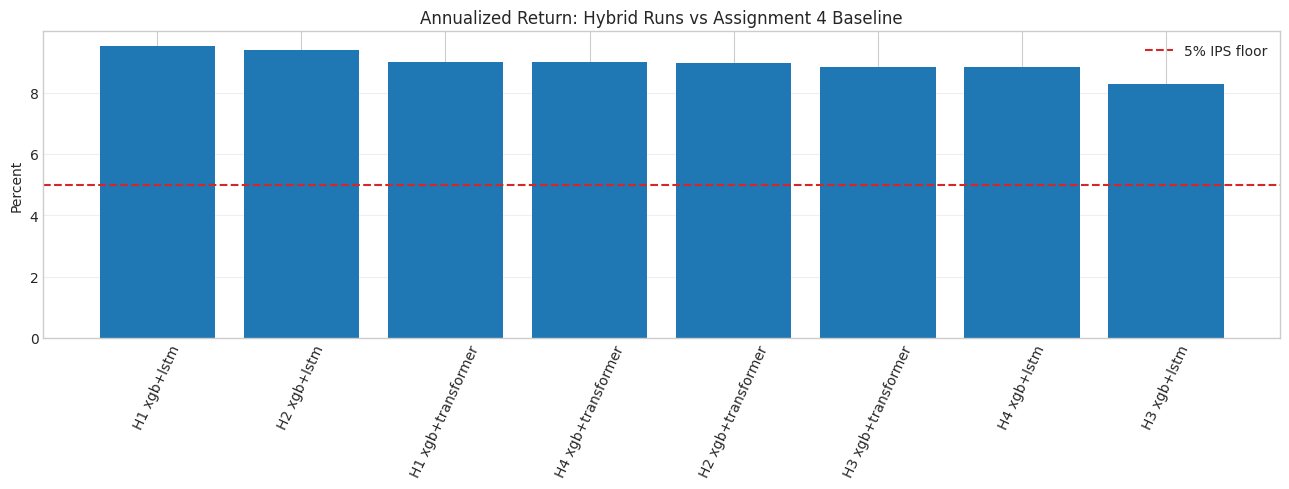

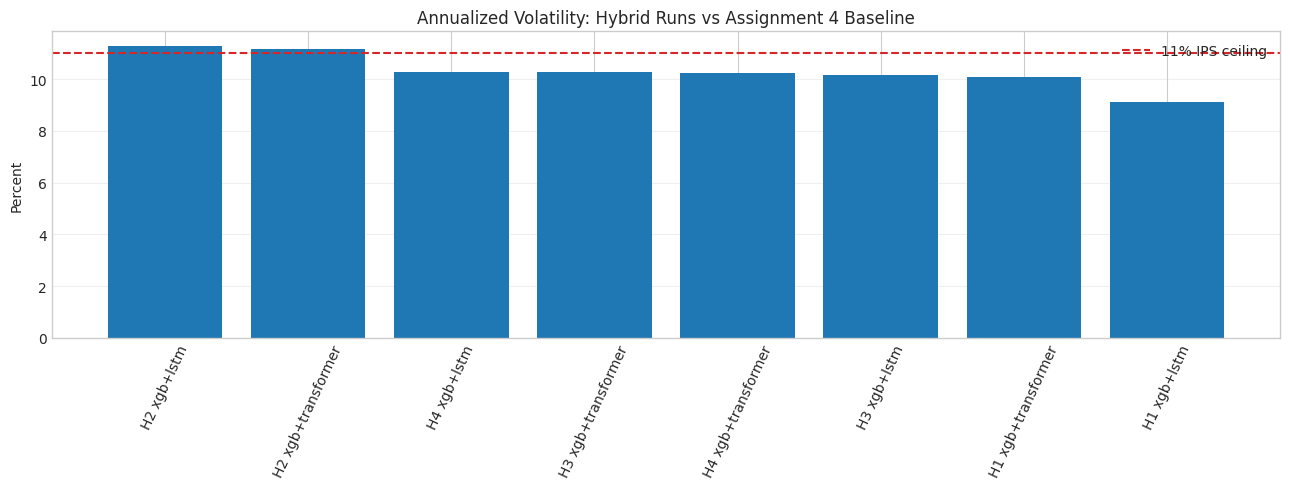

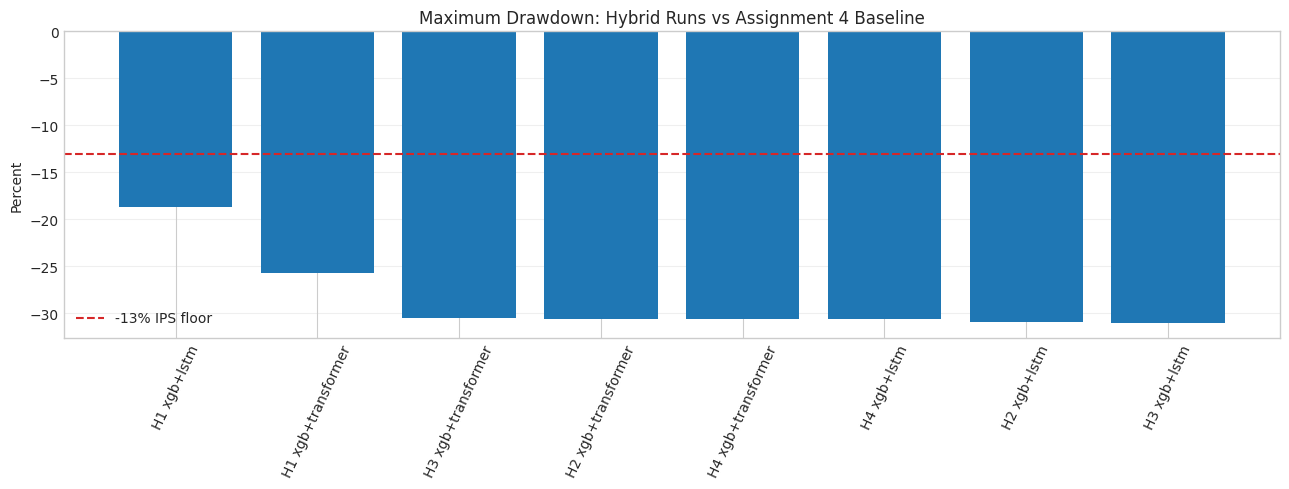

In [ ]:
def bar_metric(metric: str, title: str, target: float | None = None, target_label: str | None = None):
    plot_df = comparison.sort_values(["source", metric], ascending=[True, False]).copy()
    colors = np.where(plot_df["source"].eq("Hybrid autoresearch"), "#1f77b4", "#8c8c8c")
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(plot_df["portfolio"], plot_df[metric] * 100, color=colors)
    if target is not None:
        ax.axhline(target * 100, color="#d62728", linestyle="--", linewidth=1.5, label=target_label or "IPS target")
        ax.legend(loc="best")
    ax.set_title(title)
    ax.set_ylabel("Percent")
    ax.tick_params(axis="x", rotation=65)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    return fig, ax

bar_metric("total_return_pa", "Annualized Return: Hybrid Runs", IPS_RETURN_TARGET, "IPS 8% return target");
bar_metric("volatility_pa", "Annualized Volatility: Hybrid Runs", IPS_VOL_TARGET, "IPS 15% vol ceiling");
bar_metric("max_drawdown", "Maximum Drawdown: Hybrid Runs", IPS_MAX_DRAWDOWN_TARGET, "IPS -25% max drawdown floor");

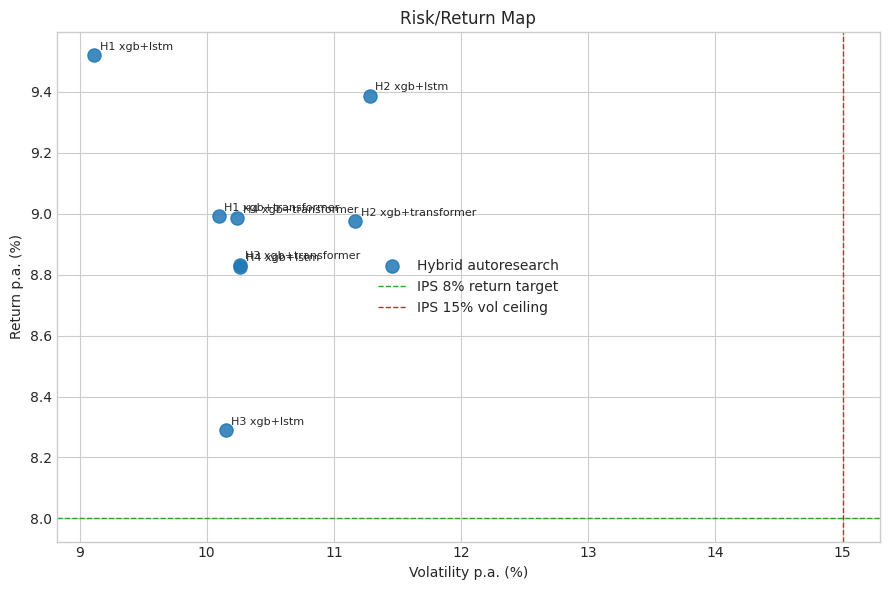

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
for source, grp in comparison.groupby("source"):
    ax.scatter(grp["volatility_pa"] * 100, grp["total_return_pa"] * 100, s=90, label=source, alpha=0.85)
    for _, row in grp.iterrows():
        ax.annotate(row["portfolio"], (row["volatility_pa"] * 100, row["total_return_pa"] * 100), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axhline(IPS_RETURN_TARGET * 100, color="#2ca02c", linestyle="--", linewidth=1, label="IPS 8% return target")
ax.axvline(IPS_VOL_TARGET * 100, color="#d62728", linestyle="--", linewidth=1, label="IPS 15% vol ceiling")
ax.set_title("Risk/Return Map")
ax.set_xlabel("Volatility p.a. (%)")
ax.set_ylabel("Return p.a. (%)")
ax.legend(loc="best")
fig.tight_layout()

## Select A Run For Path, Drawdown, Regime, And Weight Charts

In [ ]:
# Change this to any key shown below, e.g. "h1|xgb_transformer".
available_keys = [f"{r.hypothesis}|{r.model}" for _, r in best.sort_values("ips_objective").iterrows()]
SELECTED_KEY = "h1|xgb_lstm"
display(Markdown("Available keys: `" + "`, `".join(available_keys) + "`"))
display(Markdown(f"Selected run: **{SELECTED_KEY}**"))

def artifact_dir_for(row: pd.Series) -> Path:
    assets = str(row["assets"])
    asset_sig = hashlib.md5(assets.encode("utf-8")).hexdigest()[:8]
    return ARTIFACTS / f"{row['hypothesis']}_{row['model']}_{asset_sig}"

selected = best.assign(key=best["hypothesis"] + "|" + best["model"]).set_index("key").loc[SELECTED_KEY]
selected_dir = artifact_dir_for(selected)
print(selected_dir)
if not selected_dir.exists():
    raise FileNotFoundError(f"Missing artifact directory for {SELECTED_KEY}: {selected_dir}")

summary = json.loads((selected_dir / "summary.json").read_text())
taa_returns = pd.read_csv(selected_dir / "taa_daily_returns.csv", parse_dates=["date"]).set_index("date")["return"].sort_index()
weights = pd.read_csv(selected_dir / "taa_weights.csv", parse_dates=["rebalance_date"]).set_index("rebalance_date").sort_index()
signal = pd.read_csv(selected_dir / "signal.csv", parse_dates=["date"]).set_index("date")["signal"].sort_index()
proba = pd.read_csv(selected_dir / "xgb_probability.csv", parse_dates=["date"]).set_index("date")["probability"].sort_index()
forecasts = pd.read_csv(selected_dir / "return_forecasts.csv", parse_dates=["date"]).set_index("date").sort_index()

display(pd.DataFrame({"SAA": summary["saa_metrics"], "Selected TAA": summary["taa_metrics"]}).T.style.format("{:.4f}"))

Available keys: `h1|xgb_lstm`, `h1|xgb_transformer`, `h3|xgb_transformer`, `h4|xgb_transformer`, `h4|xgb_lstm`, `h2|xgb_transformer`, `h2|xgb_lstm`, `h3|xgb_lstm`

Selected run: **h1|xgb_lstm**

/home/kavin-ravi/CodingStuff/foundation_project/backtesting/artifacts/h1_xgb_lstm_82a11850


,total_return_pa,cumulative_return,volatility_pa,historical_var_95_daily,sharpe_rf2,calmar,max_drawdown
SAA,0.0849,5.3511,0.1041,-0.0093,0.6444,0.2781,-0.3054
Selected TAA,0.0952,6.8603,0.0911,-0.0085,0.8242,0.5085,-0.1872


## Cumulative Return And Drawdown Charts

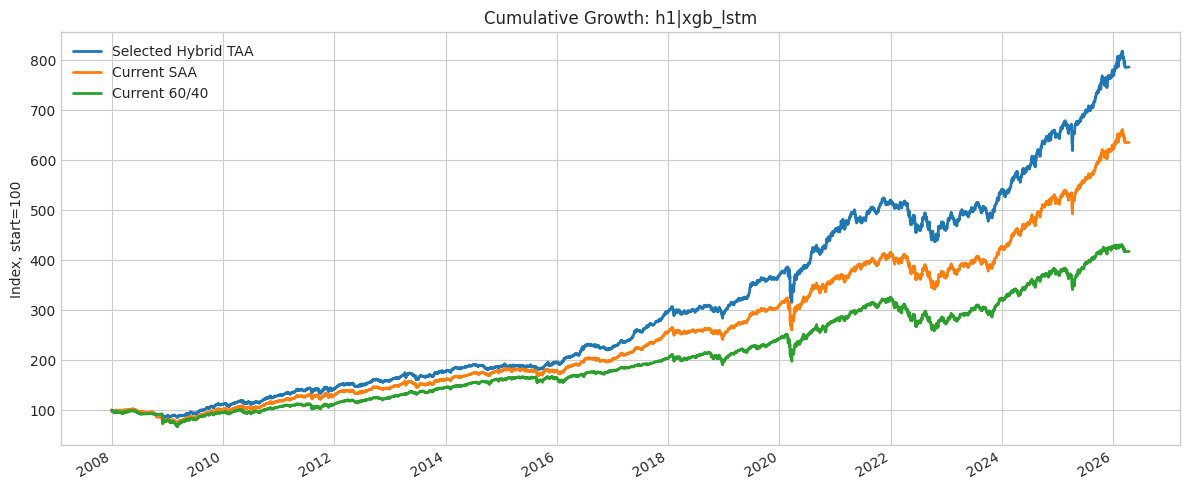

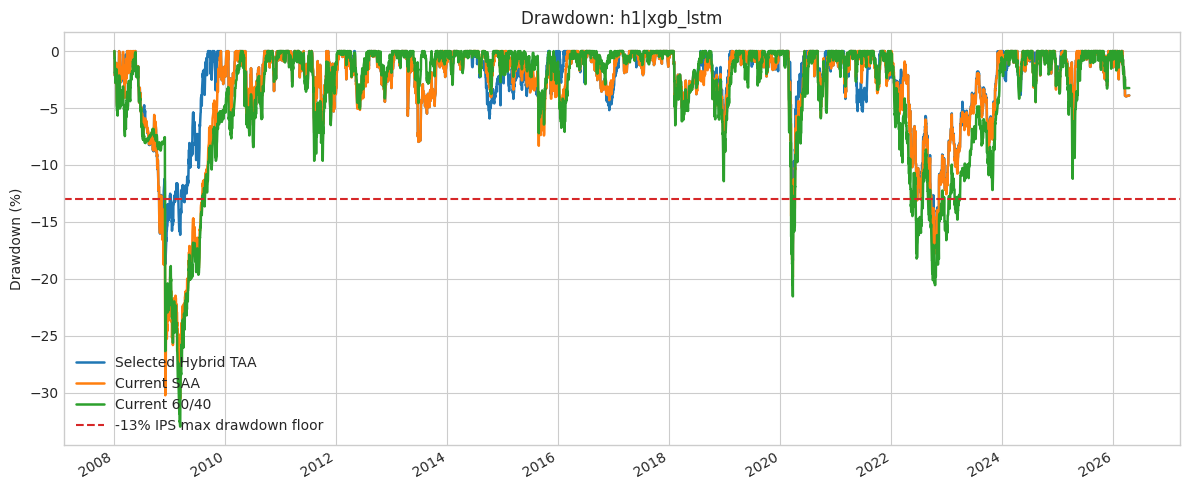

In [ ]:
from backtesting.core.backtest import feasible_returns, run_benchmark_backtest, run_saa_backtest
from backtesting.core.data import load_market_panel

assets = [a.strip() for a in str(selected["assets"]).split(",") if a.strip()]
panel = load_market_panel().slice(end=pd.Timestamp("2026-04-15"))
returns_for_assets = feasible_returns(panel.returns, asset_universe=assets)
saa = run_saa_backtest(returns_for_assets, asset_universe=assets)

series = {"Selected Hybrid TAA": taa_returns, "Current SAA": saa.daily_returns}
try:
    bench = run_benchmark_backtest(returns_for_assets, asset_universe=assets)
    series["Current 60/40"] = bench.daily_returns
except Exception as exc:
    print(f"Benchmark skipped: {exc}")

path_returns = pd.concat(series, axis=1).sort_index()
path_returns = path_returns.loc[taa_returns.index.min():taa_returns.index.max()].fillna(0.0)
equity = (1.0 + path_returns).cumprod() * 100
drawdown = equity / equity.cummax() - 1.0

fig, ax = plt.subplots(figsize=(12, 5))
equity.plot(ax=ax, linewidth=2)
ax.set_title(f"Cumulative Growth: {SELECTED_KEY}")
ax.set_ylabel("Index, start=100")
fig.tight_layout()

fig, ax = plt.subplots(figsize=(12, 5))
(drawdown * 100).plot(ax=ax, linewidth=1.8)
ax.axhline(IPS_MAX_DD_TARGET * 100, color="#d62728", linestyle="--", label="IPS -25% max drawdown floor")
ax.set_title(f"Drawdown: {SELECTED_KEY}")
ax.set_ylabel("Drawdown (%)")
ax.legend(loc="lower left")
fig.tight_layout()

## Regime And Signal Charts

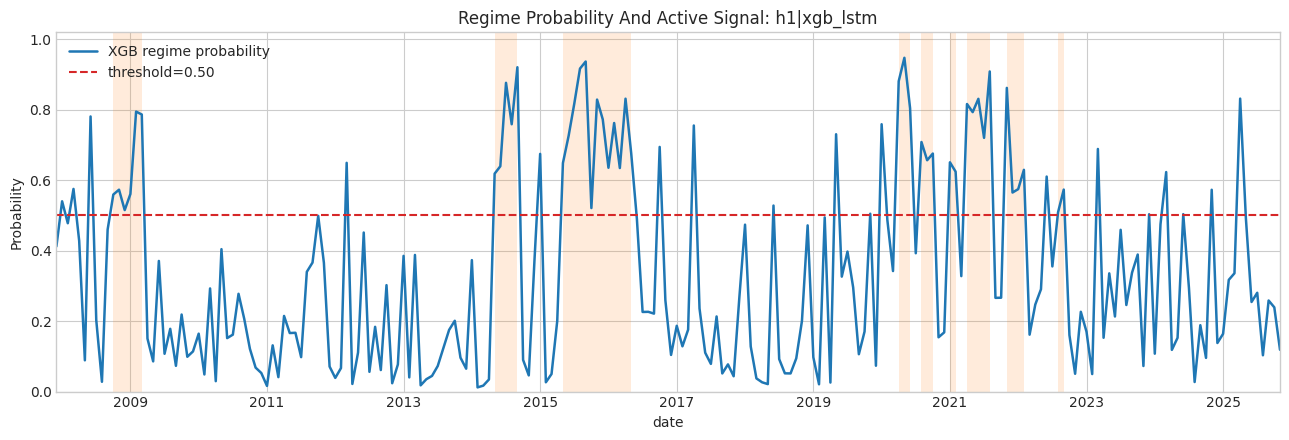

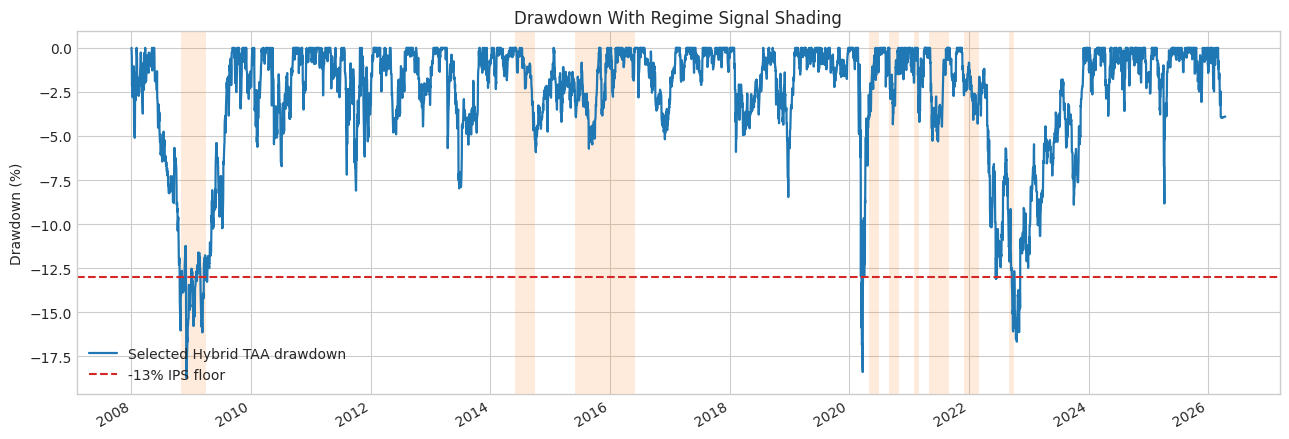

In [ ]:
def shade_active_signal(ax, signal_series: pd.Series, color="#ff7f0e", alpha=0.15):
    active = signal_series.ne(0)
    if not active.any():
        return
    groups = active.ne(active.shift()).cumsum()
    for _, segment in signal_series[active].groupby(groups[active]):
        ax.axvspan(segment.index.min(), segment.index.max(), color=color, alpha=alpha, linewidth=0)

fig, ax = plt.subplots(figsize=(13, 4.5))
proba.plot(ax=ax, color="#1f77b4", linewidth=1.8, label="XGB regime probability")
ax.axhline(float(selected["threshold"]), color="#d62728", linestyle="--", label=f"threshold={selected['threshold']:.2f}")
shade_active_signal(ax, signal)
ax.set_title(f"Regime Probability And Active Signal: {SELECTED_KEY}")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1.02)
ax.legend(loc="best")
fig.tight_layout()

fig, ax = plt.subplots(figsize=(13, 4.5))
(drawdown["Selected Hybrid TAA"] * 100).plot(ax=ax, color="#1f77b4", linewidth=1.6, label="Selected Hybrid TAA drawdown")
shade_active_signal(ax, signal)
ax.axhline(IPS_MAX_DD_TARGET * 100, color="#d62728", linestyle="--", label="IPS -25% max drawdown floor")
ax.set_title("Drawdown With Regime Signal Shading")
ax.set_ylabel("Drawdown (%)")
ax.legend(loc="lower left")
fig.tight_layout()

## Weight And Forecast Diagnostics

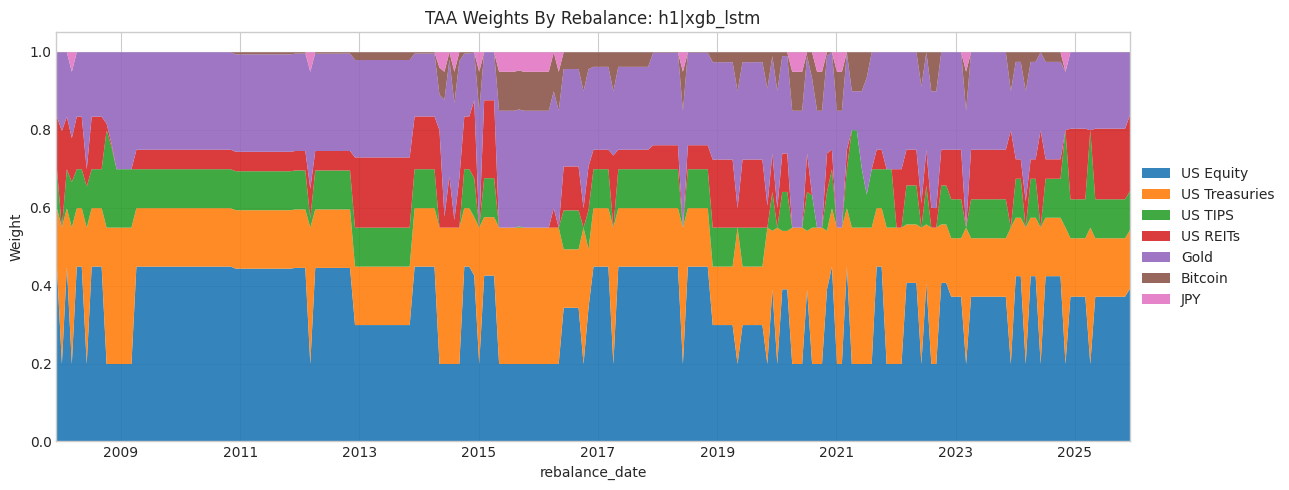

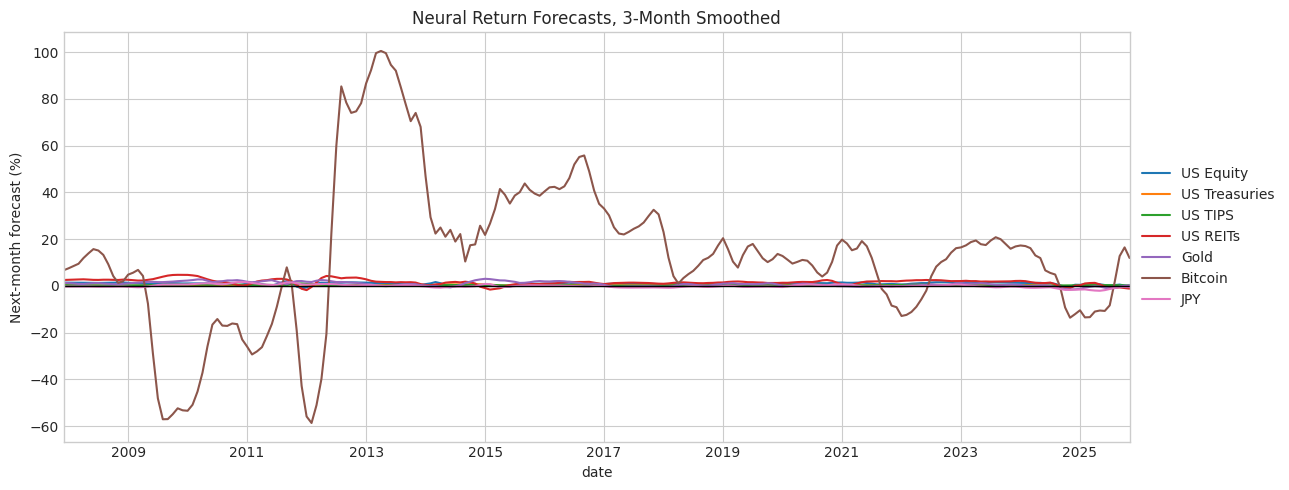

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
weights.plot.area(ax=ax, linewidth=0, alpha=0.9)
ax.set_title(f"TAA Weights By Rebalance: {SELECTED_KEY}")
ax.set_ylabel("Weight")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
fig.tight_layout()

fig, ax = plt.subplots(figsize=(13, 5))
(forecasts * 100).rolling(3, min_periods=1).mean().plot(ax=ax, linewidth=1.5)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Neural Return Forecasts, 3-Month Smoothed")
ax.set_ylabel("Next-month forecast (%)")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
fig.tight_layout()

## Walk-Forward Fold Charts

,fold,test_start,test_end,return_pa,max_drawdown,n_days
0,1,2007-12-31 00:00:00,2009-05-31 00:00:00,-3.39%,-18.72%,369
1,2,2009-06-30 00:00:00,2010-11-30 00:00:00,21.11%,-6.72%,371
2,3,2010-12-31 00:00:00,2012-05-31 00:00:00,9.08%,-8.10%,370
3,4,2012-06-30 00:00:00,2013-11-30 00:00:00,11.81%,-7.97%,370
4,5,2013-12-31 00:00:00,2015-05-31 00:00:00,3.40%,-5.92%,425
5,6,2015-06-30 00:00:00,2016-11-30 00:00:00,9.62%,-4.93%,446
6,7,2016-12-31 00:00:00,2018-05-31 00:00:00,17.34%,-5.90%,443
7,8,2018-06-30 00:00:00,2019-11-30 00:00:00,12.48%,-8.46%,444
8,9,2019-12-31 00:00:00,2021-05-31 00:00:00,13.93%,-18.39%,517
9,10,2021-06-30 00:00:00,2022-11-30 00:00:00,-0.78%,-16.67%,519


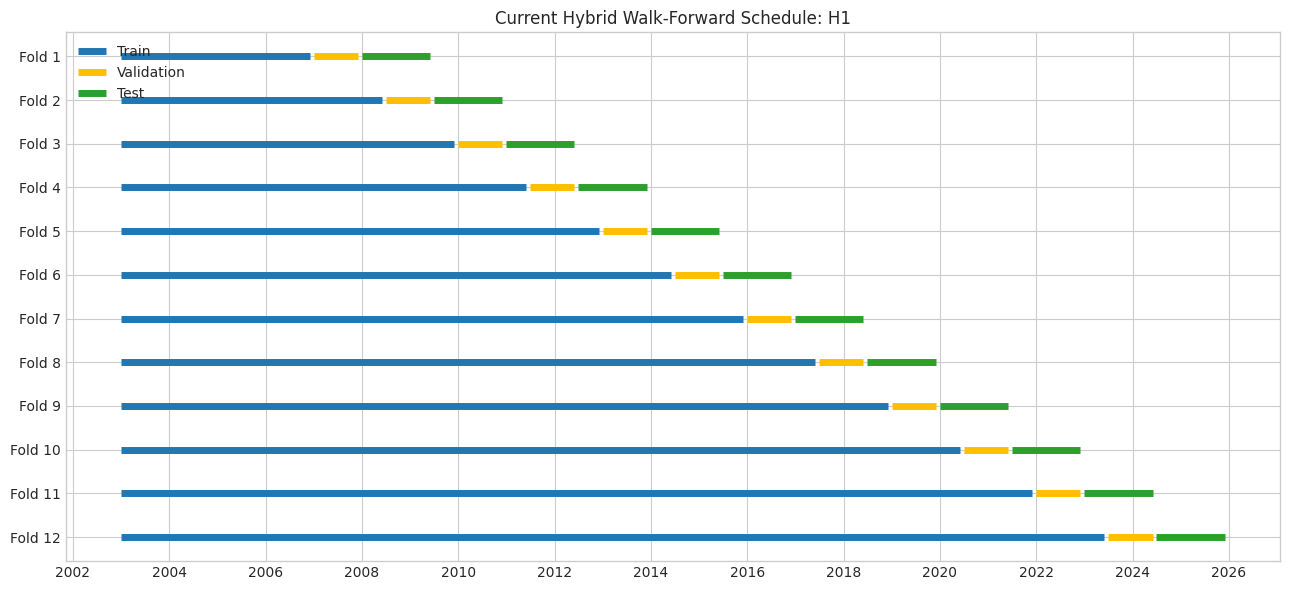

In [ ]:
from backtesting.prepare import make_folds, prepare_dataset

hypothesis_name = str(selected["hypothesis"])
hyp, X, y = prepare_dataset(hypothesis_name, panel=panel)
folds = make_folds(pd.DatetimeIndex(X.index))

fig, ax = plt.subplots(figsize=(13, 6))
for i, fold in enumerate(folds, start=1):
    yloc = len(folds) - i + 1
    ax.plot([fold.train.min(), fold.train.max()], [yloc, yloc], color="#1f77b4", linewidth=5, solid_capstyle="butt", label="Train" if i == 1 else None)
    ax.plot([fold.validation.min(), fold.validation.max()], [yloc, yloc], color="#ffbf00", linewidth=5, solid_capstyle="butt", label="Validation" if i == 1 else None)
    ax.plot([fold.test.min(), fold.test.max()], [yloc, yloc], color="#2ca02c", linewidth=5, solid_capstyle="butt", label="Test" if i == 1 else None)
ax.set_yticks(range(1, len(folds) + 1))
ax.set_yticklabels([f"Fold {i}" for i in range(len(folds), 0, -1)])
ax.set_title(f"Current Hybrid Walk-Forward Schedule: {hypothesis_name.upper()}")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left")
fig.tight_layout()

fold_rows = []
for fold in folds:
    test_rets = taa_returns.loc[pd.Timestamp(fold.test.min()):pd.Timestamp(fold.test.max())]
    if test_rets.empty:
        continue
    eq = (1 + test_rets).cumprod()
    years = len(test_rets) / 252
    fold_rows.append({
        "fold": fold.fold_id,
        "test_start": fold.test.min(),
        "test_end": fold.test.max(),
        "return_pa": eq.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan,
        "max_drawdown": (eq / eq.cummax() - 1).min(),
        "n_days": len(test_rets),
    })
current_fold_metrics = pd.DataFrame(fold_rows)
display(current_fold_metrics.style.format({"return_pa": "{:.2%}", "max_drawdown": "{:.2%}"}))

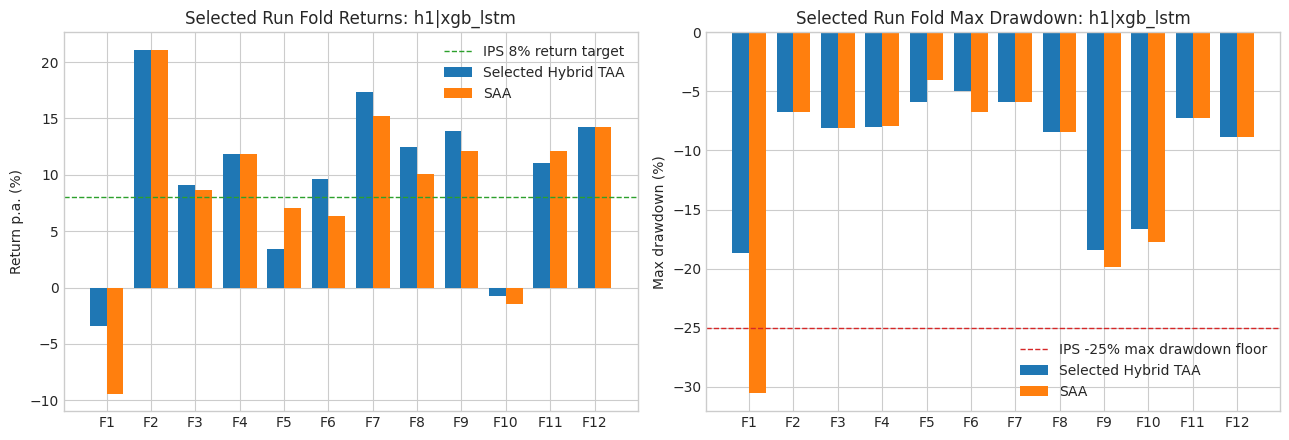

In [ ]:
# Walk-forward fold charts for the selected hybrid run.
# We rebuild the fold boundaries from the hypothesis monthly index, then
# compute fold-level metrics from the saved daily return series.

from backtesting.prepare import prepare_dataset, make_folds
from backtesting.core.data import load_market_panel
from backtesting.core.backtest import compute_metrics

hyp_name = str(selected["hypothesis"])
panel = load_market_panel().slice(end=pd.Timestamp("2026-04-15"))
_, X, _ = prepare_dataset(hyp_name, panel=panel)
folds = make_folds(pd.DatetimeIndex(X.index))

if not folds:
    raise RuntimeError("No walk-forward folds available for fold charts.")

# Daily returns already loaded earlier for the selected run.
# - `taa_returns`: selected hybrid TAA daily returns (Series)
# - `saa.daily_returns`: SAA daily returns over the same asset universe (Series)

def fold_daily_slice(daily: pd.Series, fold) -> pd.Series:
    start = pd.Timestamp(pd.DatetimeIndex(fold.test).min()).to_period("M").to_timestamp("M")
    end = pd.Timestamp(pd.DatetimeIndex(fold.test).max()).to_period("M").to_timestamp("M")
    return daily.loc[(daily.index >= start) & (daily.index <= end)].dropna()

rows = []
for fold in folds:
    taa_seg = fold_daily_slice(taa_returns, fold)
    saa_seg = fold_daily_slice(saa.daily_returns, fold)
    if taa_seg.empty or saa_seg.empty:
        continue
    taa_m = compute_metrics(taa_seg)
    saa_m = compute_metrics(saa_seg)
    rows.append({
        "fold": f"F{fold.fold_id}",
        "taa_return_pa": float(taa_m["total_return_pa"]),
        "saa_return_pa": float(saa_m["total_return_pa"]),
        "taa_max_drawdown": float(taa_m["max_drawdown"]),
        "saa_max_drawdown": float(saa_m["max_drawdown"]),
    })

fold_df = pd.DataFrame(rows)
if fold_df.empty:
    raise RuntimeError("No fold segments overlapped the selected run's daily returns.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(fold_df))
width = 0.38

axes[0].bar(x - width / 2, fold_df["taa_return_pa"] * 100, width, label="Selected Hybrid TAA")
axes[0].bar(x + width / 2, fold_df["saa_return_pa"] * 100, width, label="SAA")
axes[0].axhline(IPS_RETURN_TARGET * 100, color="#2ca02c", linestyle="--", linewidth=1, label="IPS 8% return target")
axes[0].set_title(f"Selected Run Fold Returns: {SELECTED_KEY}")
axes[0].set_ylabel("Return p.a. (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(fold_df["fold"])
axes[0].legend(loc="best")

axes[1].bar(x - width / 2, fold_df["taa_max_drawdown"] * 100, width, label="Selected Hybrid TAA")
axes[1].bar(x + width / 2, fold_df["saa_max_drawdown"] * 100, width, label="SAA")
axes[1].axhline(IPS_MAX_DD_TARGET * 100, color="#d62728", linestyle="--", linewidth=1, label="IPS -25% max drawdown floor")
axes[1].set_title(f"Selected Run Fold Max Drawdown: {SELECTED_KEY}")
axes[1].set_ylabel("Max drawdown (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(fold_df["fold"])
axes[1].legend(loc="best")

fig.tight_layout()

## Regime History From Selected Hybrid Run

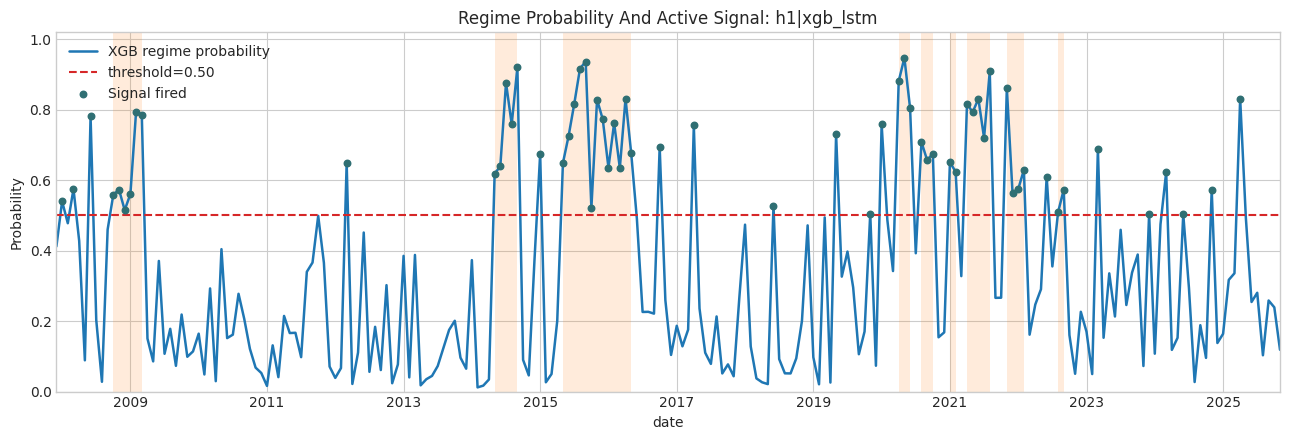

In [ ]:
# Regime chart for the selected hybrid run.
# Requires `proba` and `signal` from the selected artifact load above.

def shade_active_signal(ax, signal_series: pd.Series, color="#ff7f0e", alpha=0.15):
    active = signal_series.ne(0)
    if not active.any():
        return
    groups = active.ne(active.shift()).cumsum()
    for _, segment in signal_series[active].groupby(groups[active]):
        ax.axvspan(segment.index.min(), segment.index.max(), color=color, alpha=alpha, linewidth=0)

fig, ax = plt.subplots(figsize=(13, 4.5))
proba.plot(ax=ax, color="#1f77b4", linewidth=1.8, label="XGB regime probability")
ax.axhline(float(selected["threshold"]), color="#d62728", linestyle="--", label=f"threshold={float(selected['threshold']):.2f}")
shade_active_signal(ax, signal)

fired = signal.ne(0)
if fired.any():
    fired_idx = signal.index[fired]
    ax.scatter(fired_idx, proba.reindex(fired_idx), s=22, color="#2f6f73", label="Signal fired", zorder=3)

ax.set_title(f"Regime Probability And Active Signal: {SELECTED_KEY}")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1.02)
ax.legend(loc="best")
fig.tight_layout()

## Notes For Report Use

- `readable_best_results.csv` is the clean summary table for one row per hypothesis/model combo.
- `readable_all_trials.csv` is the readable trial-disclosure table.
- `readable_baseline_comparison.csv` is a foundation-only comparison table for hybrid runs.
- The current hybrid walk-forward curves are out-of-sample by fold, but repeated sweeps over the same folds still create model-selection bias. For a final report, reserve a final untouched holdout before claiming live robustness.